### data augmentation. 
ref: https://github.com/pytorch/vision/blob/main/references/segmentation/transforms.py 


In [1]:
import torch
import numpy as np 
from glob import glob
import rasterio as rio 
from pyrsimg import imsShow 
from notebooks import config
from utils.utils import read_scenes
from torchvision.transforms import v2
from utils.data_aug import GaussianNoise


In [2]:
patch_size = 512  ## patch size setting
### traset
paths_scene_tra, paths_truth_tra = config.paths_scene_tra, config.paths_truth_tra
print(f'train scenes: {len(paths_scene_tra)}')
### valset
paths_valset = sorted(glob(f'data/dset/valset/patch_{patch_size}/*'))  ## for model prediction 
print(f'vali patch: {len(paths_valset)}')


train scenes: 171
vali patch: 208


In [3]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra[0:10], paths_truth_tra[0:10])


In [4]:
scene_truth = np.concatenate([scenes_arr[0], truths_arr[0][:, :, np.newaxis]], axis=-1)
print(scene_truth.shape)  # (H, W, C+1) 


(1253, 1329, 7)


### numpy to tensor

In [5]:
print(scene_truth.shape)
scene_truth_ = v2.ToImage()(scene_truth)  # to PIL Image
print(scene_truth_.shape)


(1253, 1329, 7)
torch.Size([7, 1253, 1329])


### preprocessing, scene -> patch
random cropping  
 

In [6]:
transform_random  = v2.RandomCrop(size=(512, 512), padding = 100, fill=0)


In [7]:
patch_ptruth = transform_random(scene_truth_)
patch, ptruth = patch_ptruth[0:6], patch_ptruth[6:7]  ## separate patch and truth
patch, ptruth = patch.numpy().transpose((1, 2, 0)), ptruth.numpy().transpose((1, 2, 0))


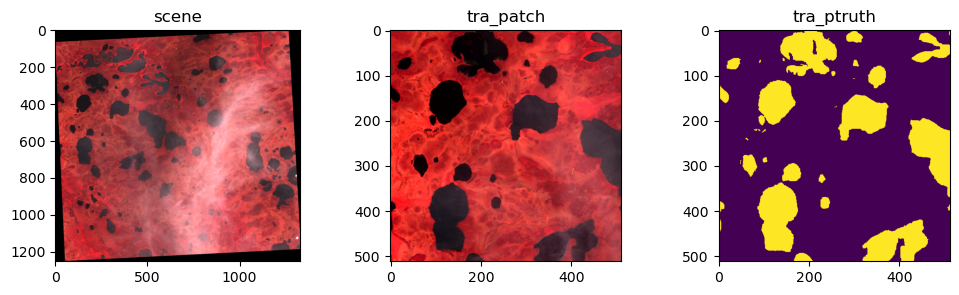

In [8]:
col_bands_list = [(3,2,1), (3,2,1), (0,0,0)]
imsShow([scene_truth_.numpy().transpose((1, 2, 0)), patch, ptruth], 
              clip_list=[2, 2, 2], 
              img_name_list=['scene','tra_patch','tra_ptruth'], 
              color_bands_list=col_bands_list,
              figsize=(12, 3));


### random augmentation
random flipping   
random noisy   
random rotation   


In [9]:
# transform_random = v2.RandomHorizontalFlip(p=0.3)  
# transform_random = v2.RandomVerticalFlip(p=0.3)  
transform_random = GaussianNoise(mean = 0, sigma_max=0.1, p=0.3)  
# transform_random = v2.RandomApply([v2.RandomRotation(degrees=180)], p=0.3) 



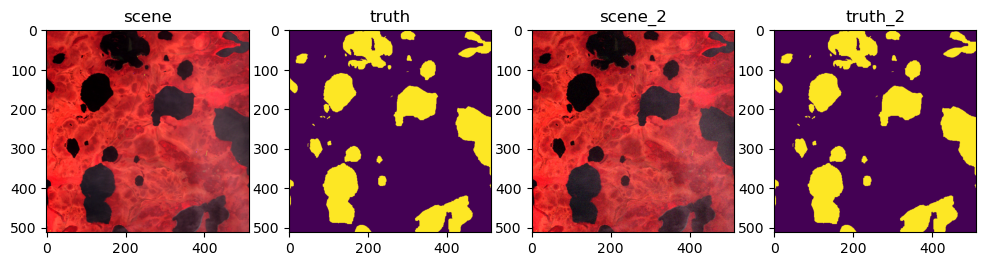

In [16]:
patch_ptruth_ = transform_random(patch_ptruth) 
patch_, ptruth_ = patch_ptruth_[0:6], patch_ptruth_[6:7]  ## separate patch and truth
patch_, ptruth_ = patch_.numpy().transpose((1, 2, 0)), ptruth_.numpy().transpose((1, 2, 0))
col_bands_list = [(3,2,1), (0,0,0), (3,2,1), (0,0,0)]
imsShow([patch, ptruth, patch_, ptruth_], 
              clip_list=[2, 2, 2, 2], 
              img_name_list=['scene','truth','scene_2','truth_2'], 
              color_bands_list=col_bands_list,
              figsize=(12, 3));


### merge all data augmentation

In [ ]:
## combine transforms
transforms = v2.Compose([
    v2.ToImage(),  # numpy.array to tensor 
    v2.RandomApply([v2.RandomRotation(degrees=180)], p=0.3),    
    v2.RandomCrop(size=(512, 512), padding = 100), 
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    GaussianNoise(mean = 0, sigma_max=0.1, p=0.3)    
    ]) 


In [13]:
patch_truth_ = transforms(scene_truth)  # to (C, H, W) for transforms


In [14]:
patch_ = patch_truth_[0:-1]
ptruth_ = patch_truth_[6:7]  ## separate patch and truth
patch_, ptruth_ = patch_.numpy().transpose((1, 2, 0)), ptruth_.numpy().transpose((1, 2, 0))


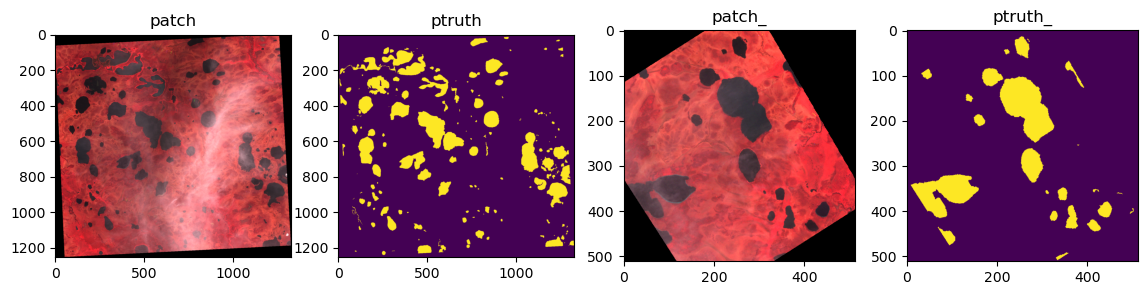

In [130]:
scene, struth = scene_truth[:,:,0:6], scene_truth[:,:,6:7]
col_bands_list = [(3,2,1), (0,0,0), (3,2,1), (0,0,0)]
imsShow([scene, struth, patch_, ptruth_], 
              clip_list=[2, 2, 2, 2], 
              img_name_list=['patch', 'ptruth','patch_','ptruth_'], 
              color_bands_list=col_bands_list,
              figsize=(14, 3));
